In [25]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#Get a feel for the table

In [26]:
df = pd.read_csv("Manufacture Data Clean Final.csv", encoding="latin1")
df.head()

,Job,SerialNumber,StockCode,StockDescription,TestDate,UnitType,Tester name,PassFail,TesterEmpNumber,FaultDesc,...,FaultDesc4,FaultFixTime4,FaultDesc5,FaultFixTime5,FaultResolution,Comments,TotalFixTime,AssEmpName,AssDate,FixCost
0,JOB-000001,SERIAL-000001,STOCK-000057,PRODUCT-000057,04/10/2025,UNIT-000014,Tester F,F,106,Trapped Wires,...,NaN,0,NaN,0,"Wiring issue corrected, continuity checked and...",Trapped Wires identified during test; unit did...,90,Assembler H,06/10/2025,£76.50
1,JOB-000001,SERIAL-000002,STOCK-000051,PRODUCT-000051,14/10/2025,UNIT-000033,Tester L,F,112,Broken Wires,...,NaN,0,NaN,0,"Wiring issue corrected, continuity checked and...",Broken Wires identified during test; unit did ...,15,Assembler C,17/10/2025,£12.75
2,JOB-000001,SERIAL-000003,STOCK-000113,PRODUCT-000113,24/10/2025,UNIT-000066,Tester F,F,106,Incorrectly Wired,...,NaN,0,NaN,0,"Wiring issue corrected, continuity checked and...",Incorrectly Wired identified during test; unit...,20,Assembler J,25/10/2025,£17.00
3,JOB-000001,SERIAL-000004,STOCK-000119,PRODUCT-000119,03/10/2025,UNIT-000043,Tester L,F,112,Wires Not Fitted,...,NaN,0,NaN,0,"Wiring issue corrected, continuity checked and...",Wires Not Fitted identified during test; unit ...,25,Assembler E,05/10/2025,£21.25
4,JOB-000002,SERIAL-000005,STOCK-000066,PRODUCT-000066,13/10/2025,UNIT-000060,Tester F,F,106,Loose Wires,...,NaN,0,NaN,0,"Wiring issue corrected, continuity checked and...",Loose Wires identified during test; unit did n...,30,Assembler L,16/10/2025,£25.50


In [27]:
#getting a feel for total test passees vs Fails

In [28]:
df['PassFail'].value_counts()

PassFail
P    9559
F    3141
Name: count, dtype: int64

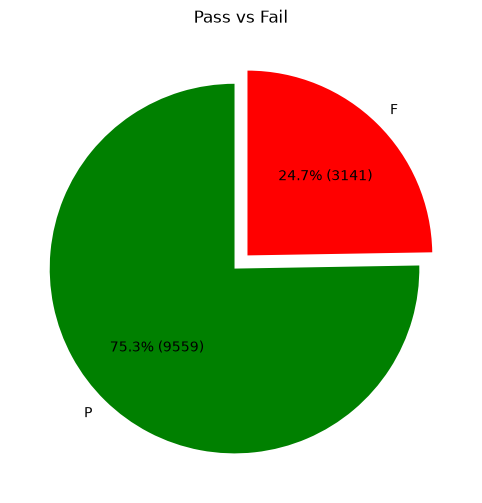

In [47]:


counts = df['PassFail'].value_counts()
color_map = {'P': 'green', 'F': 'red'}
colors = [color_map[i] for i in counts.index]

plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=counts.index,
    colors=colors,
    autopct=lambda p: f'{p:.1f}% ({int(p*sum(counts)/100)})',
    startangle=90,
    explode=[0.05, 0.05]
)
plt.title("Pass vs Fail")
plt.show()



#Checking how many of the 5 possible fault descriptions for a failed test have been used in the sample

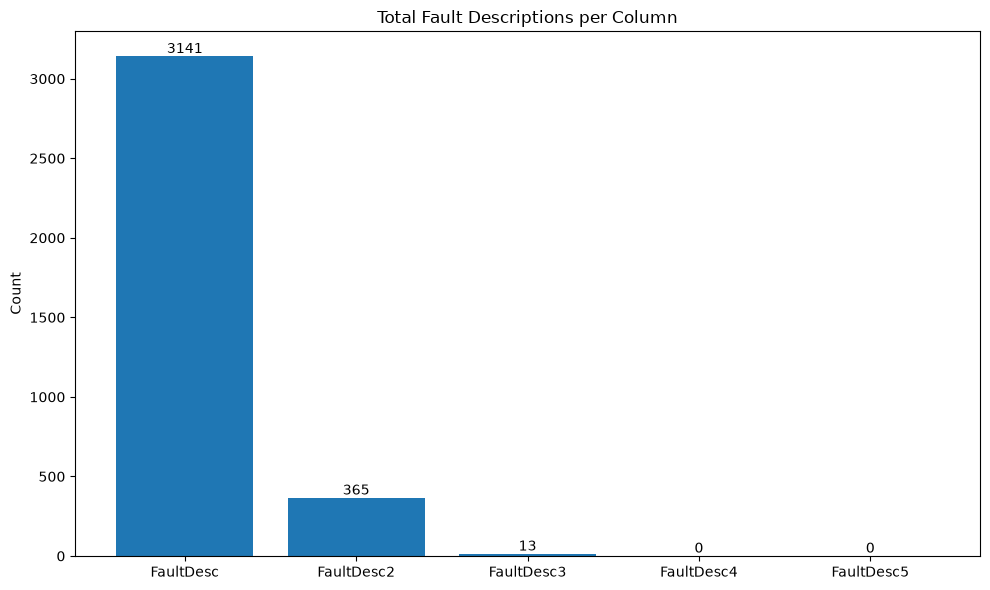

In [30]:
cols = ['FaultDesc', 'FaultDesc2', 'FaultDesc3', 'FaultDesc4', 'FaultDesc5']

# Count non‑null entries in each column
counts = df[cols].notna().sum()

plt.figure(figsize=(10,6))

# Capture bar objects
bars = plt.bar(counts.index, counts.values)

# Add value labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(height),
        ha='center',
        va='bottom'
    )

plt.ylabel("Count")
plt.title("Total Fault Descriptions per Column")
plt.tight_layout()
plt.show()

#Whats the trend on Quality Issues per month ?

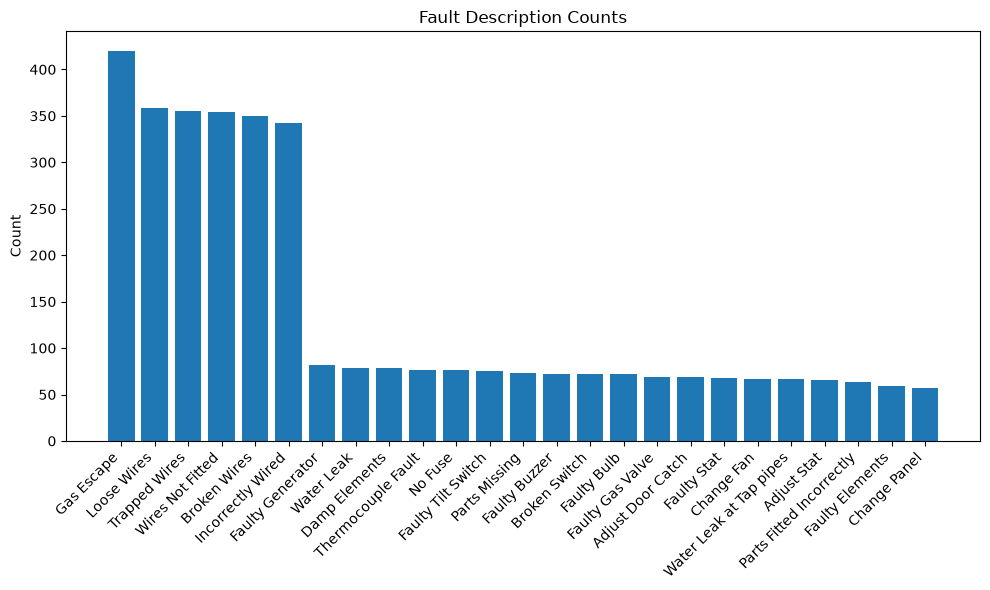

In [31]:


# Select all fault description columns
fault_cols = ['FaultDesc', 'FaultDesc2', 'FaultDesc3', 'FaultDesc4', 'FaultDesc5']

# Combine them into one long series
faults = df[fault_cols].stack().dropna()

# Count each fault type
fault_counts = faults.value_counts()

# Bar chart
plt.figure(figsize=(10,6))
plt.bar(fault_counts.index, fault_counts.values)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Count")
plt.title("Fault Description Counts")
plt.tight_layout()
plt.show()

#What were the total Failed Tests per month ?

TestMonth
Oct 2025    478
Nov 2025    455
Dec 2025    443
Jan 2026    425
Feb 2026    389
Mar 2026    314
Apr 2026    252
May 2026    215
Jun 2026    170
dtype: int64


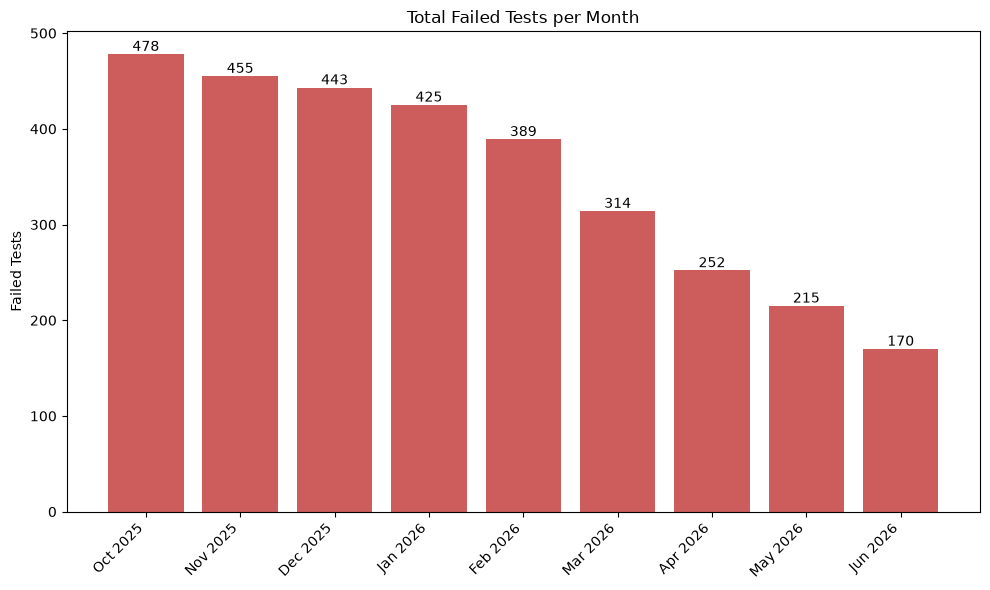

In [32]:


df['TestDate'] = pd.to_datetime(df['TestDate'], dayfirst=True)
df['TestMonth'] = df['TestDate'].dt.to_period('M')

failed_per_month = df[df['PassFail'] == 'F'].groupby('TestMonth').size()
failed_per_month.index = failed_per_month.index.strftime('%b %Y')

print(failed_per_month)

plt.figure(figsize=(10,6))
bars = plt.bar(failed_per_month.index, failed_per_month.values, color='indianred')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(int(height)),
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45, ha='right')
plt.ylabel("Failed Tests")
plt.title("Total Failed Tests per Month")
plt.tight_layout()
plt.show()

#What did the ratio of passes to fails look like ?

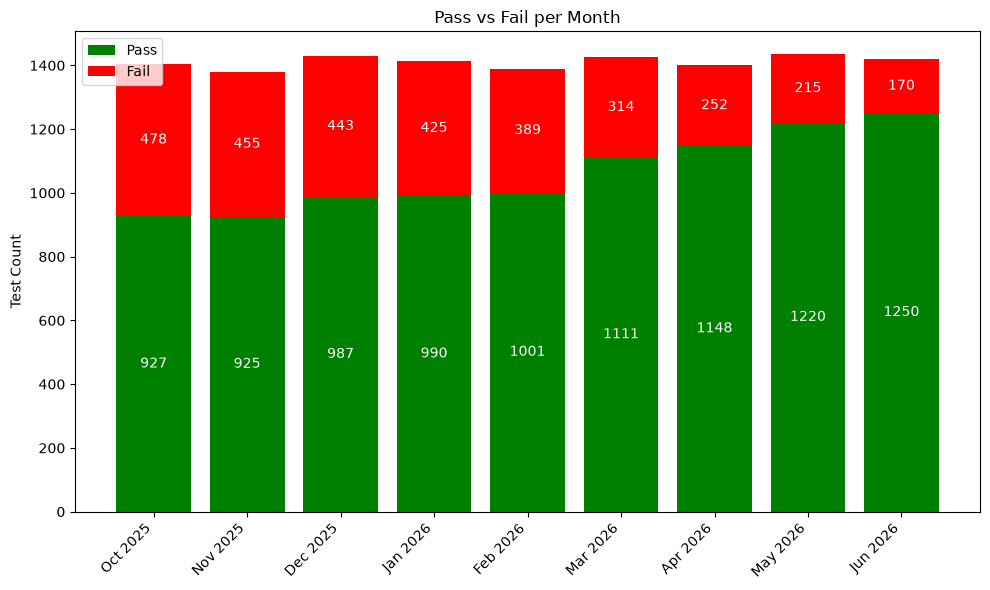

In [33]:


df['TestDate'] = pd.to_datetime(df['TestDate'], dayfirst=True)
df['TestMonth'] = df['TestDate'].dt.to_period('M')

monthly_counts = df.groupby(['TestMonth', 'PassFail']).size().unstack(fill_value=0)
monthly_counts = monthly_counts.reindex(columns=['P', 'F'], fill_value=0)
monthly_counts.index = monthly_counts.index.strftime('%b %Y')

plt.figure(figsize=(10,6))

pass_bars = plt.bar(monthly_counts.index, monthly_counts['P'], color='green', label='Pass')
fail_bars = plt.bar(monthly_counts.index, monthly_counts['F'], bottom=monthly_counts['P'], color='red', label='Fail')

for bar in pass_bars:
    height = bar.get_height()
    if height > 0:
        plt.text(bar.get_x() + bar.get_width()/2, height/2, str(int(height)), ha='center', va='center', color='white')

for bar, base in zip(fail_bars, monthly_counts['P']):
    height = bar.get_height()
    if height > 0:
        plt.text(bar.get_x() + bar.get_width()/2, base + height/2, str(int(height)), ha='center', va='center', color='white')

plt.xticks(rotation=45, ha='right')
plt.ylabel("Test Count")
plt.title("Pass vs Fail per Month")
plt.legend()
plt.tight_layout()
plt.show()

#What was the rate of failure over the time period ?

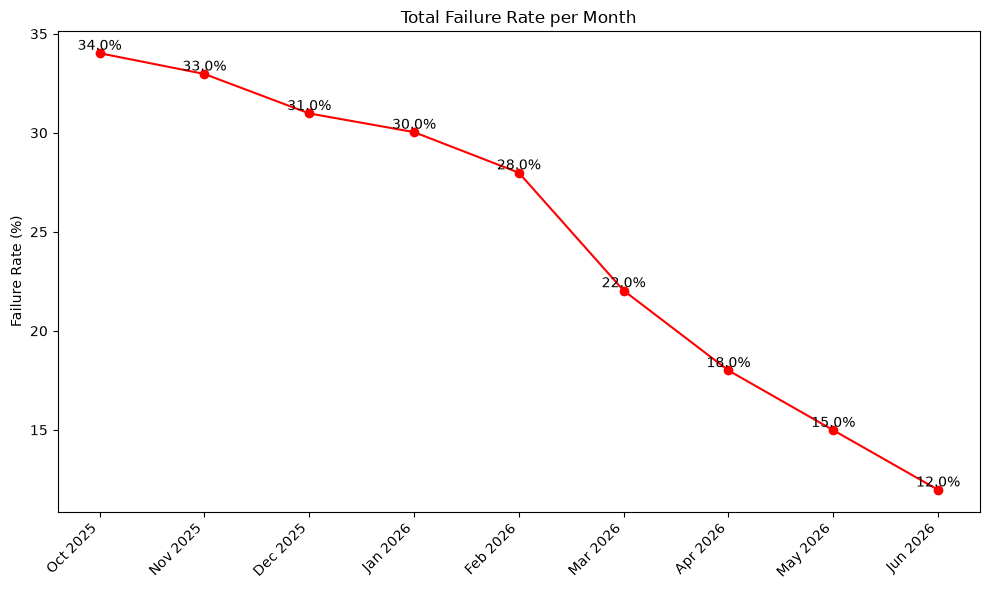

In [34]:


df['TestDate'] = pd.to_datetime(df['TestDate'], dayfirst=True)
df['TestMonth'] = df['TestDate'].dt.to_period('M')

monthly_counts = df.groupby(['TestMonth', 'PassFail']).size().unstack(fill_value=0)
monthly_counts = monthly_counts.reindex(columns=['P', 'F'], fill_value=0)

failure_rate = (monthly_counts['F'] / (monthly_counts['P'] + monthly_counts['F'])) * 100
failure_rate.index = failure_rate.index.strftime('%b %Y')

plt.figure(figsize=(10,6))
plt.plot(failure_rate.index, failure_rate.values, marker='o', color='red')

for x, y in zip(failure_rate.index, failure_rate.values):
    plt.text(x, y, f'{y:.1f}%', ha='center', va='bottom')

plt.xticks(rotation=45, ha='right')
plt.ylabel("Failure Rate (%)")
plt.title("Total Failure Rate per Month")
plt.tight_layout()
plt.show()

#Data tells us wiring related issues are huge factor - what did thiss look like per month ?

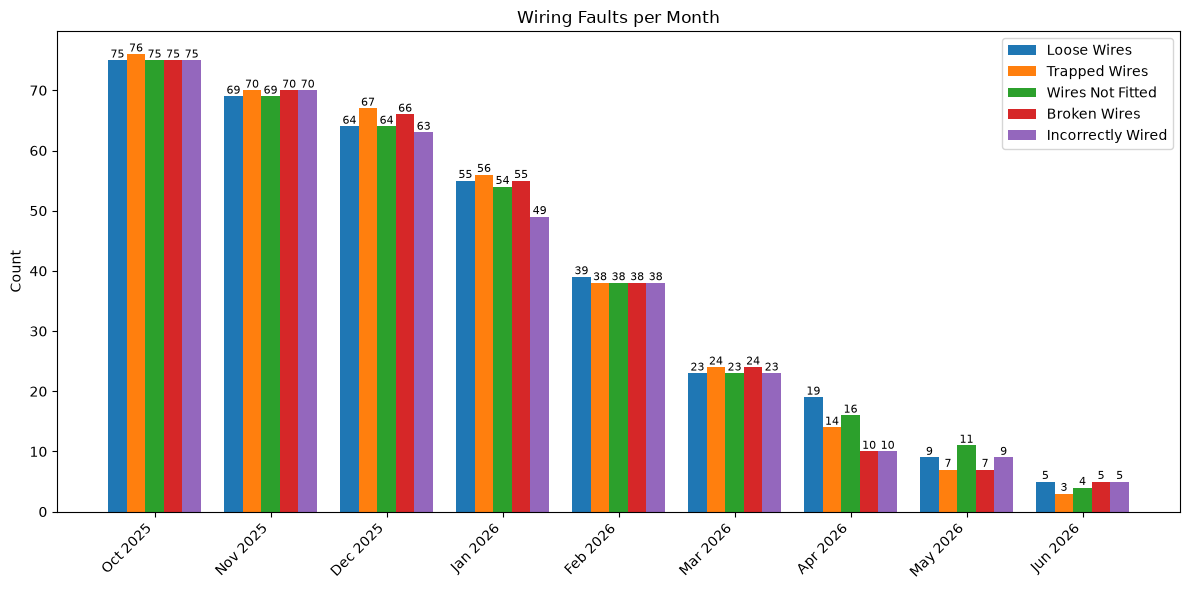

In [35]:


df['TestDate'] = pd.to_datetime(df['TestDate'], dayfirst=True)
df['TestMonth'] = df['TestDate'].dt.to_period('M')

fault_cols = ['FaultDesc', 'FaultDesc2', 'FaultDesc3', 'FaultDesc4', 'FaultDesc5']
wire_faults = ['Loose Wires', 'Trapped Wires', 'Wires Not Fitted', 'Broken Wires', 'Incorrectly Wired']

# Melt fault columns into one column, keeping TestMonth alongside each fault entry
faults_long = df.melt(id_vars='TestMonth', value_vars=fault_cols, value_name='Fault').dropna(subset=['Fault'])

# Keep only the wire-related faults
faults_long = faults_long[faults_long['Fault'].isin(wire_faults)]

# Count occurrences per month per fault type
monthly_wire_faults = faults_long.groupby(['TestMonth', 'Fault']).size().unstack(fill_value=0)
monthly_wire_faults = monthly_wire_faults.reindex(columns=wire_faults, fill_value=0)
monthly_wire_faults.index = monthly_wire_faults.index.strftime('%b %Y')

# Grouped bar chart - individual bar per fault type, per month
months = monthly_wire_faults.index
x = np.arange(len(months))
n_faults = len(wire_faults)
width = 0.8 / n_faults

plt.figure(figsize=(12,6))

for i, fault in enumerate(wire_faults):
    values = monthly_wire_faults[fault].values
    bars = plt.bar(x + i*width, values, width, label=fault)
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            plt.text(bar.get_x() + bar.get_width()/2, height, str(int(height)), ha='center', va='bottom', fontsize=8)

plt.xticks(x + width*(n_faults-1)/2, months, rotation=45, ha='right')
plt.ylabel("Count")
plt.title("Wiring Faults per Month")
plt.legend()
plt.tight_layout()
plt.show()

#same for gas escapes - what was the story here ?

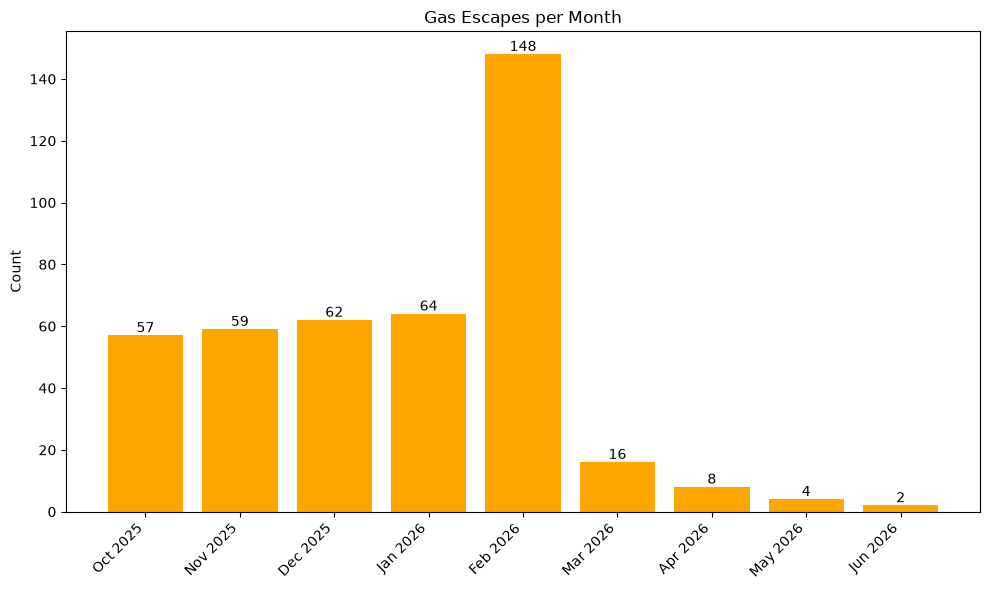

In [36]:


df['TestDate'] = pd.to_datetime(df['TestDate'], dayfirst=True)
df['TestMonth'] = df['TestDate'].dt.to_period('M')

fault_cols = ['FaultDesc', 'FaultDesc2', 'FaultDesc3', 'FaultDesc4', 'FaultDesc5']

faults_long = df.melt(id_vars='TestMonth', value_vars=fault_cols, value_name='Fault').dropna(subset=['Fault'])
gas_escapes = faults_long[faults_long['Fault'] == 'Gas Escape']

gas_per_month = gas_escapes.groupby('TestMonth').size()
gas_per_month.index = gas_per_month.index.strftime('%b %Y')

plt.figure(figsize=(10,6))
bars = plt.bar(gas_per_month.index, gas_per_month.values, color='orange')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(int(height)),
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45, ha='right')
plt.ylabel("Count")
plt.title("Gas Escapes per Month")
plt.tight_layout()
plt.show()

#Money in parts and labour wasted per month fixing manufacturing issues

TestMonth
Oct 2025    20043.00
Nov 2025    19915.50
Dec 2025    18487.50
Jan 2026    17888.25
Feb 2026    16460.25
Mar 2026    12541.75
Apr 2026    10476.25
May 2026     8640.25
Jun 2026     7539.50
Name: FixCostValue, dtype: float64


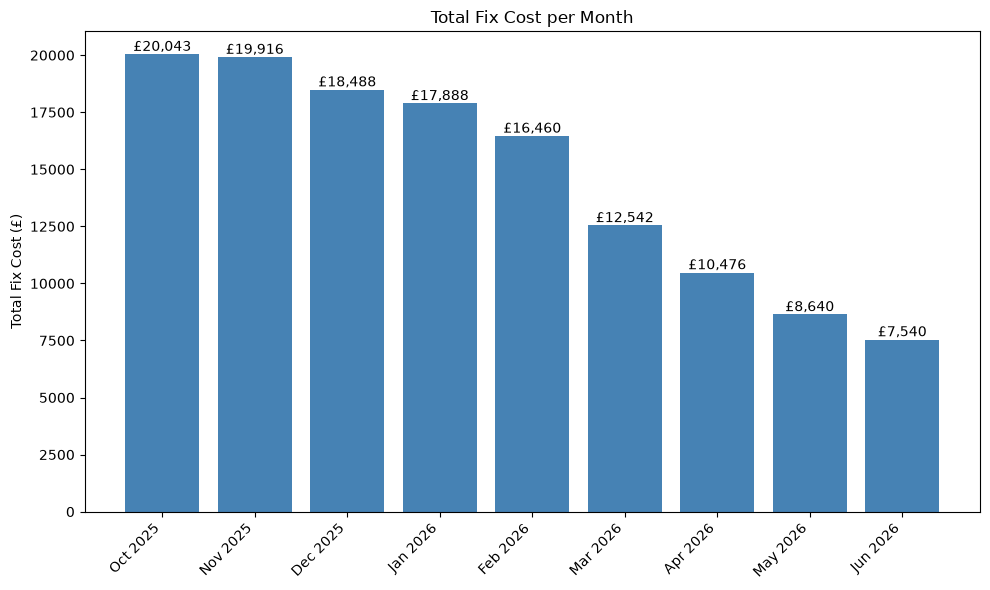

In [37]:


df['TestDate'] = pd.to_datetime(df['TestDate'], dayfirst=True)
df['TestMonth'] = df['TestDate'].dt.to_period('M')

df['FixCostValue'] = df['FixCost'].replace('[£,]', '', regex=True).astype(float)

fixcost_per_month = df.groupby('TestMonth')['FixCostValue'].sum()
fixcost_per_month.index = fixcost_per_month.index.strftime('%b %Y')

print(fixcost_per_month)

plt.figure(figsize=(10,6))
bars = plt.bar(fixcost_per_month.index, fixcost_per_month.values, color='steelblue')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'£{height:,.0f}',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45, ha='right')
plt.ylabel("Total Fix Cost (£)")
plt.title("Total Fix Cost per Month")
plt.tight_layout()
plt.show()

#Time wasted per month fixing manufacturing errors

TestMonth
Oct 2025    393.000000
Nov 2025    390.500000
Dec 2025    362.500000
Jan 2026    350.750000
Feb 2026    322.750000
Mar 2026    245.916667
Apr 2026    205.416667
May 2026    169.416667
Jun 2026    147.833333
Name: TotalFixTime, dtype: float64


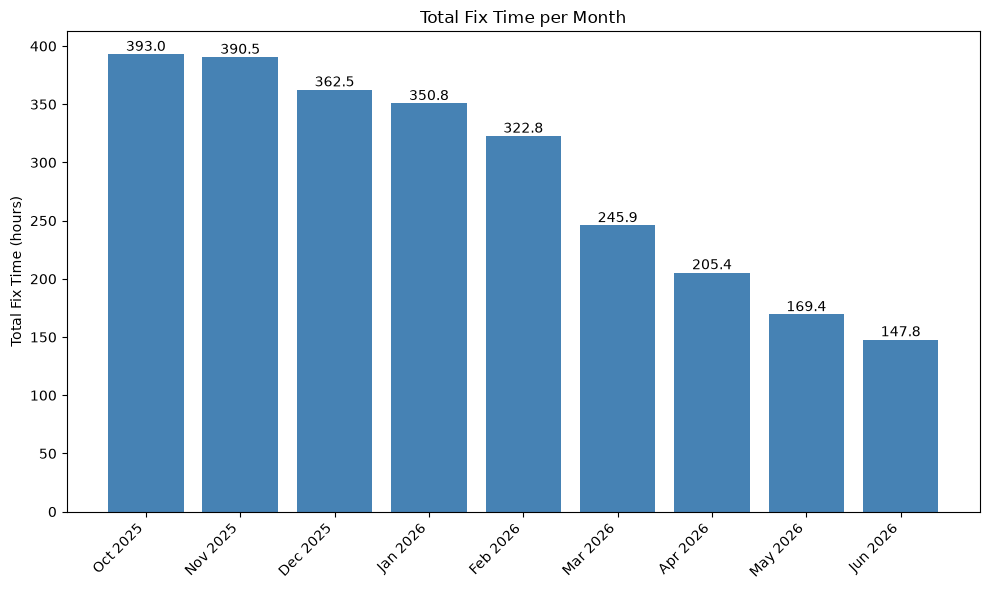

In [38]:


df['TestDate'] = pd.to_datetime(df['TestDate'], dayfirst=True)
df['TestMonth'] = df['TestDate'].dt.to_period('M')

fixtime_per_month = df.groupby('TestMonth')['TotalFixTime'].sum() / 60
fixtime_per_month.index = fixtime_per_month.index.strftime('%b %Y')

print(fixtime_per_month)

plt.figure(figsize=(10,6))
bars = plt.bar(fixtime_per_month.index, fixtime_per_month.values, color='steelblue')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.1f}',
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45, ha='right')
plt.ylabel("Total Fix Time (hours)")
plt.title("Total Fix Time per Month")
plt.tight_layout()
plt.show()

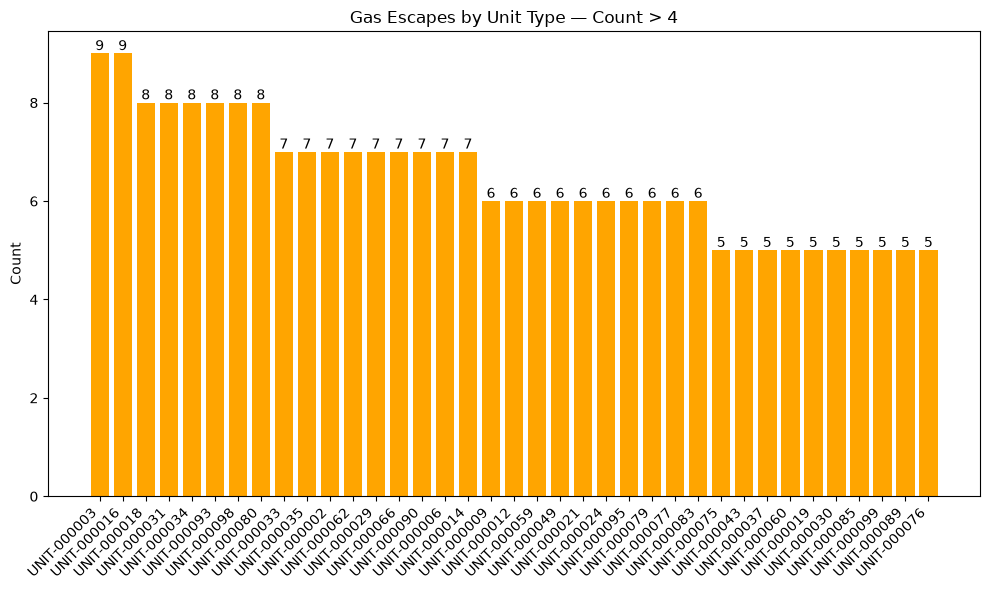

In [45]:


fault_cols = ['FaultDesc', 'FaultDesc2', 'FaultDesc3', 'FaultDesc4', 'FaultDesc5']

faults_long = df.melt(id_vars='UnitType', value_vars=fault_cols, value_name='Fault').dropna(subset=['Fault'])
gas_escapes = faults_long[faults_long['Fault'] == 'Gas Escape']

gas_per_unit = gas_escapes.groupby('UnitType').size().sort_values(ascending=False)
gas_per_unit = gas_per_unit[gas_per_unit > 4]

plt.figure(figsize=(10,6))
bars = plt.bar(gas_per_unit.index, gas_per_unit.values, color='orange')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(int(height)),
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45, ha='right')
plt.ylabel("Count")
plt.title("Gas Escapes by Unit Type — Count > 4")
plt.tight_layout()
plt.show()

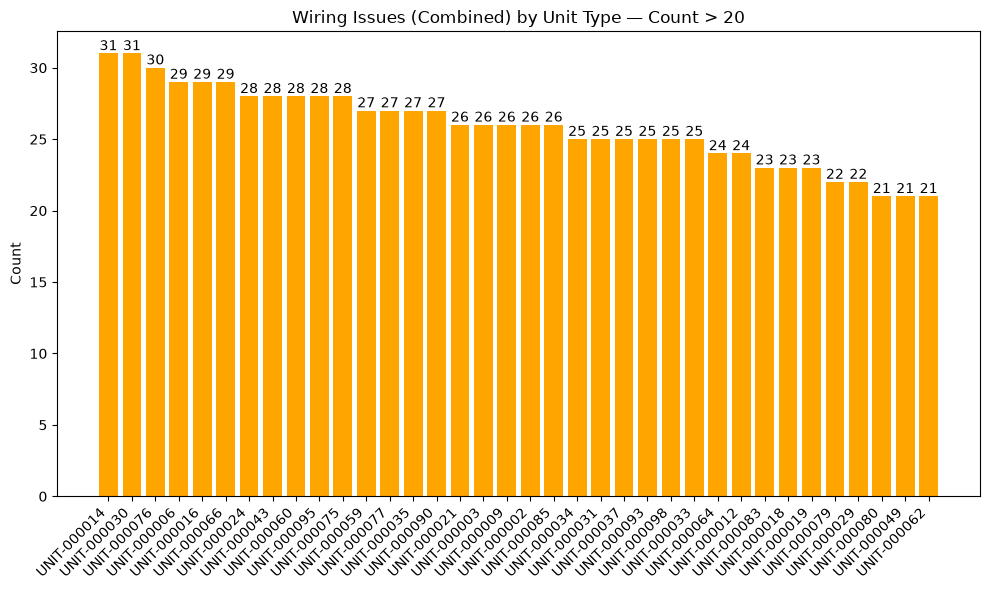

In [46]:
df = pd.read_csv("Manufacture Data Clean Final.csv", encoding="latin1")

fault_cols = ['FaultDesc', 'FaultDesc2', 'FaultDesc3', 'FaultDesc4', 'FaultDesc5']
wire_faults = ['Loose Wires', 'Trapped Wires', 'Wires Not Fitted', 'Broken Wires', 'Incorrectly Wired']

faults_long = df.melt(id_vars='UnitType', value_vars=fault_cols, value_name='Fault').dropna(subset=['Fault'])
wire_issues = faults_long[faults_long['Fault'].isin(wire_faults)]

wire_per_unit = wire_issues.groupby('UnitType').size().sort_values(ascending=False)
wire_per_unit = wire_per_unit[wire_per_unit > 20]

plt.figure(figsize=(10,6))
bars = plt.bar(wire_per_unit.index, wire_per_unit.values, color='orange')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(int(height)),
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45, ha='right')
plt.ylabel("Count")
plt.title("Wiring Issues (Combined) by Unit Type — Count > 20")
plt.tight_layout()
plt.show()

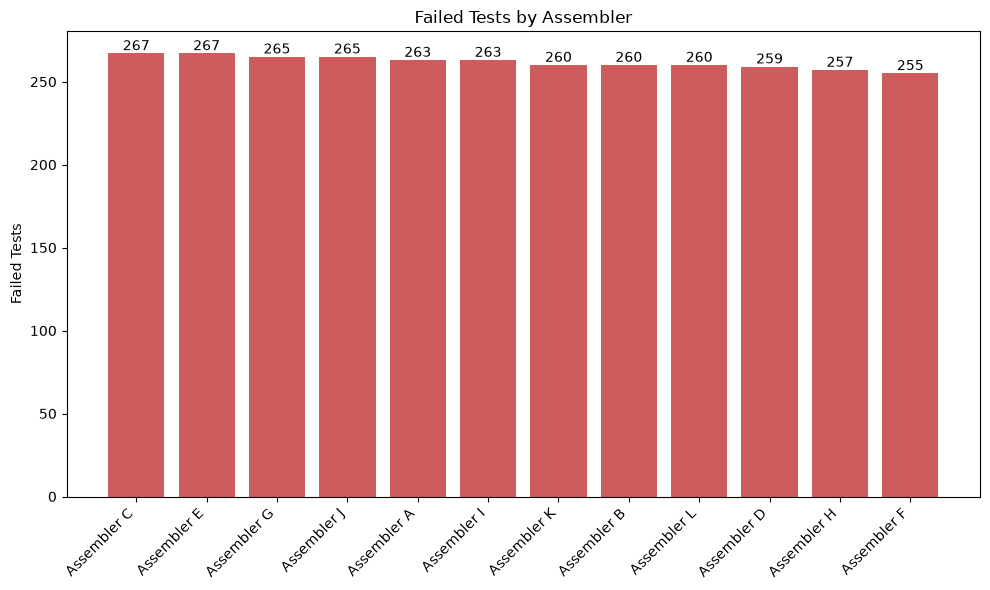

In [41]:
df = pd.read_csv("Manufacture Data Clean Final.csv", encoding="latin1")

fails = df[df['PassFail'] == 'F']

fails_per_assembler = fails.groupby('AssEmpName').size().sort_values(ascending=False)

plt.figure(figsize=(10,6))
bars = plt.bar(fails_per_assembler.index, fails_per_assembler.values, color='indianred')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        str(int(height)),
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=45, ha='right')
plt.ylabel("Failed Tests")
plt.title("Failed Tests by Assembler")
plt.tight_layout()
plt.show()